In [1]:
!pip install scikit-learn


  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/83/a4/c8e67227c680e2259c8864ae72ff48b06e16a6f51253a22167aa02a8aa4e/scikit_learn-1.9.0-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for joblib>=1.4.0 from https://files.pythonhosted.org/packages/7b/91/984aca2ec129e2757d1e4e3c81c3fcda9d0f85b74670a094cc443d9ee949/joblib-1.5.3-py3-none-any.whl.metadata
  Obtaining dependency information for threadpoolctl>=3.5.0 from https://files.pythonhosted.org/packages/32/d5/f9a850d79b0851d1d4ef6456097579a9005b31fea68726a4ae5f2d82ddd9/threadpoolctl-3.6.0-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB 660.6 kB/s eta 0:00:13
   ---------------------------------------- 0.0/8.2 MB 487.6 kB/s eta 0:00:17
   ---------------------------------------- 0.1/8.2 MB 653.6 kB/s 


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

#### load and first look

In [14]:
df=pd.read_csv("telco_customer_churn.csv")

In [15]:
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


#### handling null values

In [16]:
df.shape

(7043, 33)

In [17]:
df.dtypes

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

In [18]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [19]:
df['Churn Reason'].value_counts()

Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Service dissatisfaction                       89
Lack of self-service on Website               88
Extra data charges                            57
Moved                                         53
Lack of affordable download/upload speed      44
Limited range of services                     44
Long distance charges                         44
Poor expertise of phone support               20
Poor expertise of online support              19
Deceased                                       6
Name: c

In [20]:
df['Churn Reason'].fillna('not churned',inplace=True)

C:\Users\sibya\AppData\Local\Temp\ipykernel_1992\3307357933.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Churn Reason'].fillna('not churned',inplace=True)


In [21]:
df.isnull().sum()

CustomerID           0
Count                0
Country              0
State                0
City                 0
Zip Code             0
Lat Long             0
Latitude             0
Longitude            0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
Churn Value          0
Churn Score          0
CLTV                 0
Churn Reason         0
dtype: int64

In [22]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


#### checking churn rate

In [23]:
churn_rate=df['Churn Value'].value_counts(normalize=True)*100
print(churn_rate)

Churn Value
0    73.463013
1    26.536987
Name: proportion, dtype: float64


#### visualizing

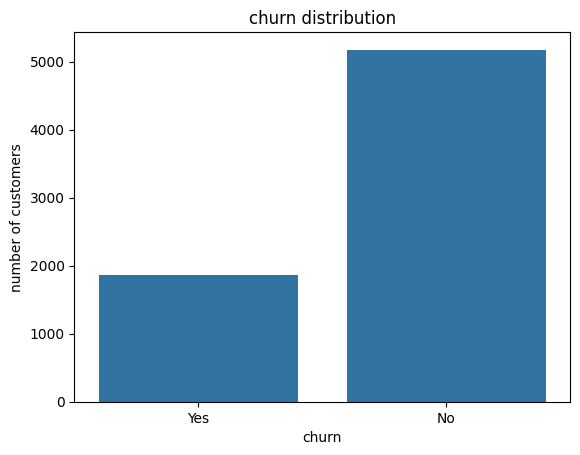

In [29]:


sns.countplot(x='Churn Label', data=df)
plt.title('churn distribution')
plt.xlabel('churn')
plt.ylabel('number of customers')
plt.savefig("churndist.png")
plt.show()

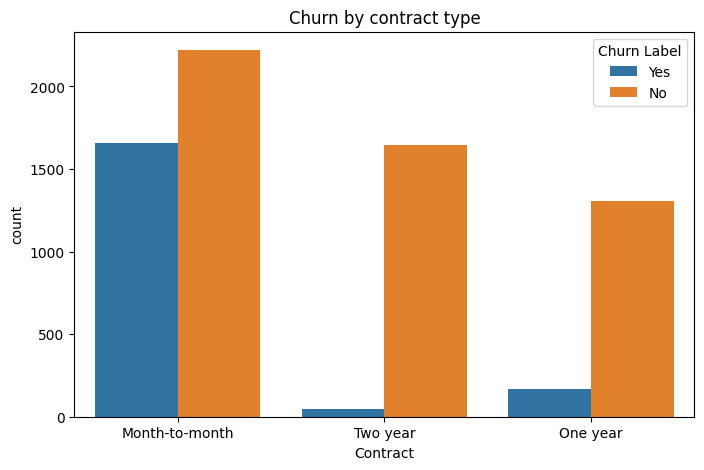

In [31]:
# Q1: Does contract type affect churn?
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn Label', data=df)
plt.title('Churn by contract type')
plt.savefig("churndist.png")
plt.show()

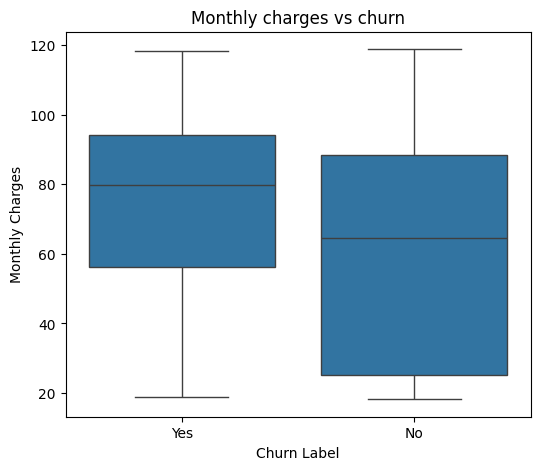

In [32]:
# Q2: Do high monthly charges lead to churn?
plt.figure(figsize=(6,5))
sns.boxplot(x='Churn Label', y='Monthly Charges', data=df)
plt.title('Monthly charges vs churn')
plt.savefig("churndist.png")
plt.show()

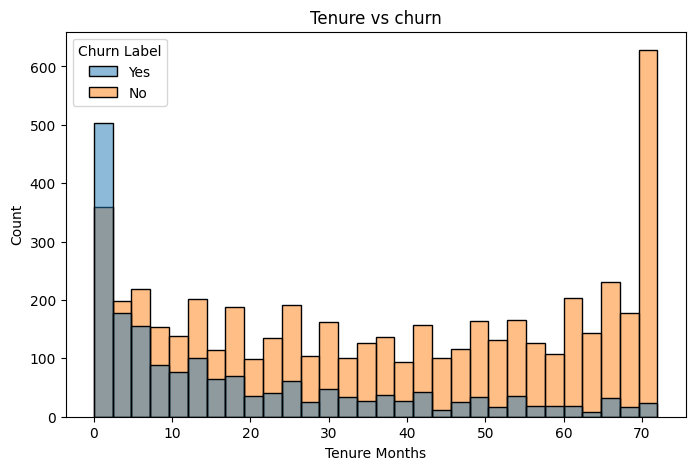

In [33]:
# Q3: Do new customers churn more?
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Tenure Months', hue='Churn Label', bins=30)
plt.title('Tenure vs churn')
plt.savefig("churndist.png")
plt.show()

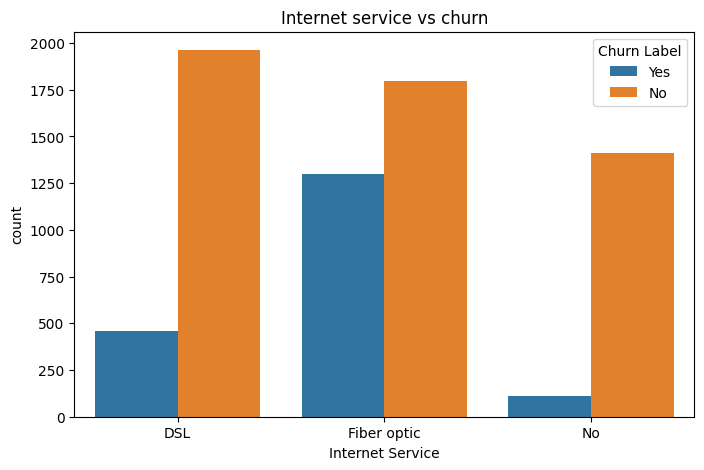

In [34]:
# Q4: Does internet service type matter?
plt.figure(figsize=(8,5))
sns.countplot(x='Internet Service', hue='Churn Label', data=df)
plt.title('Internet service vs churn')
plt.savefig("churndist.png")
plt.show()

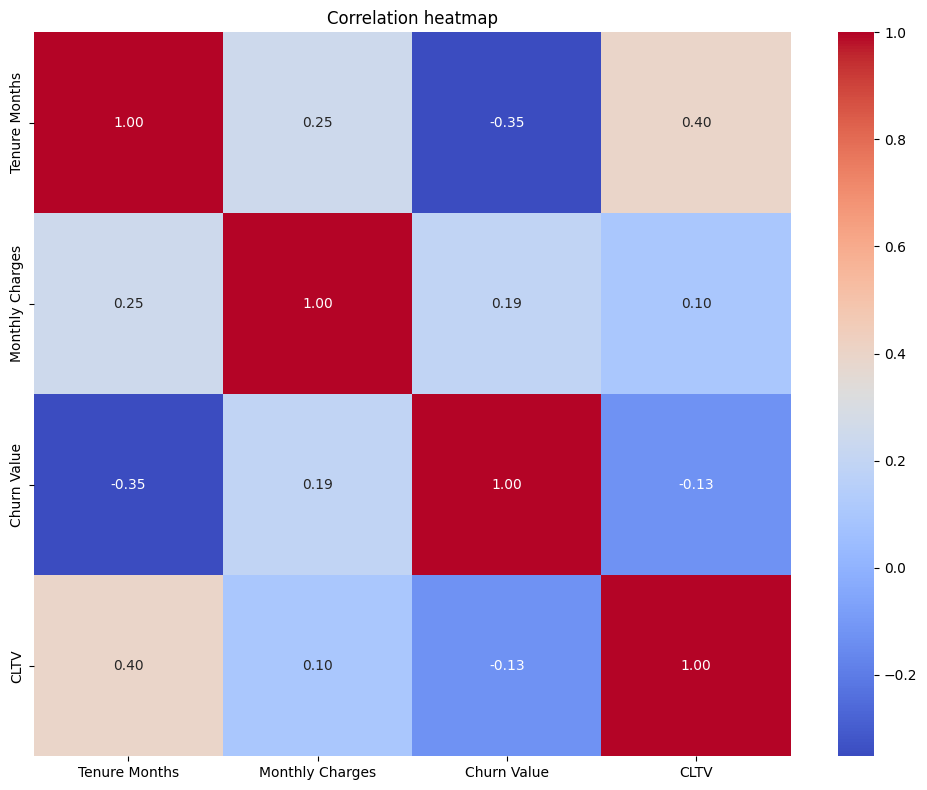

In [35]:
# Q5: Correlation heatmap — drop non-useful numeric cols first
plt.figure(figsize=(10,8))
num_cols = df.select_dtypes(include='number').drop(
    columns=['Churn Score', 'Zip Code', 'Latitude', 'Longitude', 'Count'],
    errors='ignore'
)
sns.heatmap(num_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation heatmap')
plt.tight_layout()
plt.savefig("churndist.png")
plt.show()

In [36]:
# Confirm exact column names — copy from this output
print([col for col in df.columns if any(
    x in col.lower() for x in ['churn','charge','tenure','contract','internet']
)])

['Tenure Months', 'Internet Service', 'Contract', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'Churn Reason']


#### Data cleaning & preprocessing


In [37]:
df.info

<bound method DataFrame.info of       CustomerID  Count        Country       State          City  Zip Code  \
0     3668-QPYBK      1  United States  California   Los Angeles     90003   
1     9237-HQITU      1  United States  California   Los Angeles     90005   
2     9305-CDSKC      1  United States  California   Los Angeles     90006   
3     7892-POOKP      1  United States  California   Los Angeles     90010   
4     0280-XJGEX      1  United States  California   Los Angeles     90015   
...          ...    ...            ...         ...           ...       ...   
7038  2569-WGERO      1  United States  California       Landers     92285   
7039  6840-RESVB      1  United States  California      Adelanto     92301   
7040  2234-XADUH      1  United States  California         Amboy     92304   
7041  4801-JZAZL      1  United States  California  Angelus Oaks     92305   
7042  3186-AJIEK      1  United States  California  Apple Valley     92308   

                    Lat Long   

In [40]:
# Convert TotalCharges to numeric
df['Total Charges'] = pd.to_numeric(
    df['Total Charges'],
    errors='coerce'
)

In [43]:
df['TotalCharges'].isnull().sum()


np.int64(0)

In [42]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

#### Drop unnecessary column

In [46]:
df.drop('CustomerID', axis=1, inplace=True)

In [47]:
df.head()

,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,...,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,TotalCharges
0,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,...,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,108.15
1,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,...,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,151.65
2,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,...,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved,820.50
3,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,...,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved,3046.05
4,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,...,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices,5036.30


In [49]:
df['Churn Label'] = df['Churn Label'].map({
    'Yes': 1,
    'No': 0
})

In [50]:
# Drop extra target-related columns (avoid data leakage)
df.drop(
    ['Churn Value', 'Churn Score', 'Churn Reason'],
    axis=1,
    inplace=True,
    errors='ignore'
)

In [58]:
# Scale numeric columns
import pandas as pd
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = [
    'Tenure Months',
    'Monthly Charges',
    'Total Charges'
]

df[num_cols] = scaler.fit_transform(df[num_cols])


print(df.shape)
print(df.isnull().sum().sum())
df.head()



(7043, 30)
11


,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,...,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,CLTV,TotalCharges
0,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,...,No,No,Month-to-month,Yes,Mailed check,-0.362660,-0.959649,1,3239,108.15
1,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,...,No,No,Month-to-month,Yes,Electronic check,0.197365,-0.940457,1,2701,151.65
2,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,1.159546,-0.645369,1,5372,820.50
3,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,1.330711,0.336516,1,5003,3046.05
4,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,...,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),1.294151,1.214589,1,5340,5036.30


#### Create new features

In [60]:
# Average revenue per month of tenure
df['avg_monthly_spend'] = (
    df['Total Charges'] / (df['Tenure Months'] + 1)
)
df['avg_monthly_spend']

0        4.053870
1        3.972798
2      -84.939776
3        0.409384
4        0.724206
          ...    
7038    -0.145825
7039    -0.195987
7040     0.857426
7041    -6.585391
7042     0.849313
Name: avg_monthly_spend, Length: 7043, dtype: float64

In [61]:
# Is customer new? (less than 6 months)
df['is_new_customer'] = (
    df['Tenure Months'] < 6
).astype(int)
df['is_new_customer'] 

0       1
1       1
2       1
3       1
4       1
       ..
7038    1
7039    1
7040    1
7041    1
7042    1
Name: is_new_customer, Length: 7043, dtype: int64

In [ ]:
# Count add-on services
service_cols = [
    'Phone Service',
    'Multiple Lines',
    'Online Security',
    'Online Backup',
    'Device Protection',
    'Tech Support'
]

df['num_services'] = df[service_cols].apply(
    lambda x: (x == 'Yes').sum(),
    axis=1
)

df.head()

#### Split into X and y

In [63]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn Label', axis=1)
y = df['Churn Label']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5634, 32)
(1409, 32)


In [65]:
df_original = df.copy()
df_original.to_csv(
    "churn_results.csv",
    index=False
)